# Load libraries, data and define plotting functions

## Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from joblib import Parallel, delayed
from scipy.special import logsumexp
from pathlib import Path
from scipy.stats import norm
from scipy.stats import gaussian_kde
import re
import stan
import arviz as az

import nest_asyncio
nest_asyncio.apply()

# load prepared data from data_processing.ipynb
filename = "../Data/gb_energy_data_filled.csv"
data_gb = pd.read_csv(filename)
data_gb['utc_timestamp'] = pd.to_datetime(data_gb['utc_timestamp'])
data_gb = data_gb.set_index('utc_timestamp').sort_index()
data_gb = data_gb.asfreq('h') 

data_gb['diff_price_day_ahead'] = data_gb['GB_GBN_price_day_ahead'].diff()
data_gb['diff_price_day_ahead_filled'] = data_gb['price_day_ahead_filled'].diff()

## Posterior Inspection Plotters

In [2]:


def plot_trace_and_densities(fit, param_names, num_samples, n_chains):
    total_param_number = 0
    for param in param_names:
        if param not in fit.keys():
            print(param, "not present.")
            continue
        if fit[param].ndim == 3:
            total_param_number += fit[param].shape[0] * fit[param].shape[1]
        else:
            total_param_number += fit[param].shape[0]

    fig, axes = plt.subplots(total_param_number, 2, figsize=(8, 1.5*total_param_number))
    fig_index = 0
    for param in param_names:
        if fit[param].ndim==3:
            n_row = fit[param].shape[0]
            n_col = fit[param].shape[1]
            for i in range(n_row):
                for j in range(n_col):
                    param_name =  param + "[" + str(i) + ", " + str(j) +"]"
                    posterior_draws = fit[param][i,j].reshape(num_samples, n_chains).T

                    for chain_index in range(n_chains):
                        axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                        axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)
                    axes[fig_index, 0].set_title(param_name)
                    axes[fig_index, 1].set_title(param_name)
                    fig_index += 1

        elif fit[param].ndim==2:
            if fit[param].shape[0]>1:
                n_param = fit[param].shape[0]
                for param_index in range(n_param):
                    param_name = param+'[' + str(param_index) +']'
                    posterior_draws = fit[param][param_index].reshape(num_samples, n_chains).T
                    for chain_index in range(n_chains):
                        axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                        axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)

                    axes[fig_index, 0].set_title(param_name)
                    axes[fig_index, 1].set_title(param_name)
                    fig_index += 1
            else:
                posterior_draws = fit[param][0].reshape(num_samples, n_chains).T
                for chain_index in range(n_chains):
                    axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                    axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)
                axes[fig_index, 0].set_title(param)
                axes[fig_index, 1].set_title(param)
                fig_index += 1
    plt.tight_layout()
    plt.show()



def plot_posterior_scatter_matrix(fit, param_names, num_samples, n_chains, max_points=2000):
    posterior_draws = {}
    for param in param_names:
        if param not in fit.keys():
            print(f"Parameter {param} missing from fit.")
            continue
        arr = fit[param]
        if arr.ndim == 1:
            posterior_draws[param] = arr.reshape(num_samples, n_chains).T.flatten()
        else:
            for k in range(arr.shape[0]):
                posterior_draws[f"{param}[{k+1}]"] = arr[k].reshape(num_samples, n_chains).T.flatten()

    keys = list(posterior_draws.keys())
    if len(keys) == 0:
        return

    total_points = len(next(iter(posterior_draws.values())))
    sample_idx = np.random.choice(total_points, min(total_points, max_points), replace=False)

    n = len(keys)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    for i, xi in enumerate(keys):
        for j, yj in enumerate(keys):
            ax = axes[i, j]
            if i == j:
                ax.hist(posterior_draws[xi][sample_idx], bins=30, color='lightblue')
            else:
                ax.scatter(posterior_draws[yj][sample_idx],
                           posterior_draws[xi][sample_idx],
                           s=3, alpha=0.4)
            if i == n - 1:
                ax.set_xlabel(yj)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(xi)
            else:
                ax.set_yticklabels([])

    fig.suptitle("Posterior draw scatter matrix")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

def plot_posterior_scatter_matrix_dataframe(fit: pd.DataFrame, param_names, max_points=2000):
    posterior_draws = {}
    for param in param_names:
        if param not in fit.columns:
            print(f"Parameter {param} missing from fit.")
            continue
        posterior_draws [param] = fit[param]
        
    keys = list(posterior_draws.keys())
    if len(keys) == 0:
        return

    total_points = len(next(iter(posterior_draws.values())))
    sample_idx = np.random.choice(total_points, min(total_points, max_points), replace=False)

    n = len(keys)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    for i, xi in enumerate(keys):
        for j, yj in enumerate(keys):
            ax = axes[i, j]
            if i == j:
                ax.hist(posterior_draws[xi][sample_idx], bins=30, color='lightblue')
            else:
                ax.scatter(posterior_draws[yj][sample_idx],
                           posterior_draws[xi][sample_idx],
                           s=3, alpha=0.4)
            if i == n - 1:
                ax.set_xlabel(yj)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(xi)
            else:
                ax.set_yticklabels([])

    fig.suptitle("Posterior draw scatter matrix")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()




## Predictive Sampling Functions

In [3]:
def mean_function(param_vals: pd.Series, X_data: pd.DataFrame):
    day_coef_index = [i for i in range(param_vals.shape[0]) if 'day_coef' in param_vals.keys()[i]]
    hour_coef_index = [i for i in range(param_vals.shape[0]) if 'hour_coef' in param_vals.keys()[i]]

    day_coef_vals = np.insert(param_vals.iloc[day_coef_index].to_numpy(), 0, 0.0)
    hour_coef_vals = np.insert(param_vals.iloc[hour_coef_index].to_numpy(), 0 , 0.0)
    
    mean = param_vals['overall_mean'] + param_vals['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] 
    for k in range(1,4):
        a1 = param_vals['fourier_coef.1.' + str(k)]
        a2 = param_vals['fourier_coef.2.' + str(k)]
        mean += a1* np.cos(2 * np.pi * k * X_data['time_year']) + a2 * np.sin( 2 * np.pi * k * X_data['time_year'])
    return mean.to_numpy()

def posterior_det_mean(post_df: pd.DataFrame, X_data: pd.DataFrame):    
    n_post = post_df.shape[0]
    n_data = X_data.shape[0]
    output = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        output[post_ind, :] = mean_function(post_df.iloc[post_ind,:], X_data)
    return output

def sample_latent_process(n_step: int, param_vals: pd.Series):
    alpha_v = np.exp(-param_vals['theta_v'])
    alpha_v_sq = alpha_v**2

    z_random = np.random.normal(size=n_step)
    log_vol_sample = np.empty(n_step)

    # draw initial value from the stationary distribution
    log_vol_sample[0] = param_vals['mu_v'] + param_vals['theta_v'] / np.sqrt(1 - alpha_v_sq) * z_random[0]

    jump_ind = np.random.binomial(1, param_vals['p_jump'], size=n_step)

    jump_mean_vec = jump_ind * param_vals['mu_jump']

    OU_step_sd = param_vals['sigma_v'] * np.sqrt( (1 - alpha_v_sq) / (2*param_vals['theta_v']) )
    oujp_sd = np.sqrt(OU_step_sd*OU_step_sd + jump_ind * (param_vals['sigma_jump']*param_vals['sigma_jump']))

    for t in range(1, n_step):
        mean = param_vals['mu_v'] + alpha_v * (log_vol_sample[t-1] - param_vals['mu_v']) + jump_mean_vec[t]
        log_vol_sample[t] =  mean + oujp_sd[t]*z_random[t]

    return log_vol_sample


def sample_process_one_step_predictive(param_vals: pd.Series, y_data: np.array, X_data: pd.DataFrame):
    if len(y_data) != X_data.shape[0]:
        raise ValueError('Dimension mismatch. `y_data` and `X_data` should have same length.')
    
    n_step = X_data.shape[0]

    alpha = np.exp(-param_vals['theta'])

    log_vol = sample_latent_process(n_step, param_vals)
    det_mean = mean_function(param_vals, X_data)

    sample = np.empty(n_step)
    expectation = np.empty(n_step)

    sample[0] = y_data[0]
    expectation[0] = y_data[0]
    expectation[1:] =  det_mean[1:] + alpha * (y_data[:-1] - det_mean[:-1])

    z_random = np.random.normal(size=n_step)

    OU_step_sd = np.exp(log_vol) * np.sqrt( (1 - alpha*alpha) / (2*param_vals['theta']) )

    for t in range(1, n_step):
        sample[t] =  expectation[t] + OU_step_sd[t]*z_random[t]

    return expectation, sample

def sample_process_predictive(param_vals: pd.Series, y_initial_value: float, X_data: pd.DataFrame):
    n_step = X_data.shape[0]
    alpha = np.exp(-param_vals['theta'])

    log_vol = sample_latent_process(n_step, param_vals)
    det_mean = mean_function(param_vals, X_data)

    sample = np.empty(n_step)
    sample[0] = y_initial_value

    z_random = np.random.normal(size=n_step)
    OU_step_sd = np.exp(log_vol) * np.sqrt( (1 - alpha*alpha) / (2*param_vals['theta']) )
    
    ou_random_innovations = OU_step_sd * z_random

    for t in range(1, n_step):
        sample[t] =  det_mean[t] + alpha * (sample[t-1] - det_mean[t-1]) + ou_random_innovations[t]

    return log_vol, sample

def posterior_latent_process(post: pd.DataFrame, n_step: int):
    n_post = post.shape[0]
    output = np.empty((n_post, n_step))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        output[post_ind, :] = sample_latent_process(n_step, param_vals)
    
    return output

def posterior_predictive(post: pd.DataFrame, y_initial_value: float, X_data: pd.DataFrame):
    n_steps = X_data.shape[0]
    n_post = post.shape[0]
    posterior_sample = np.empty((n_post, n_steps))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind,:]
        log_vol, sample_pred = sample_process_predictive(post.iloc[post_ind,:], y_initial_value, X_data)
        posterior_sample[post_ind,:] = sample_pred
    return posterior_sample

def posterior_one_step_predictive(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    if len(y_data) != X_data.shape[0]:
        raise ValueError('Dimension mismatch. `y_data` and `X_data` should have same length.')
    
    n_steps = X_data.shape[0]
    n_post = post.shape[0]

    one_step_expected = np.empty((n_post, n_steps))
    one_step_pred = np.empty((n_post, n_steps))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind,:]
        exp, pred = sample_process_one_step_predictive(post.iloc[post_ind,:], y_data, X_data)
        one_step_pred[post_ind,:] = pred
        one_step_expected[post_ind,:] = exp
        
    return one_step_expected, one_step_pred

## Dataframe Setup

In [4]:
training_window_size = 2*365 

final_month = data_gb.index.max().to_period("M")
validation_data = data_gb[data_gb.index.to_period("M") == final_month]
validation_data_start_date = min(validation_data.index)
validation_data_end_date = max(validation_data.index)
validation_data_days = np.unique(validation_data.index.to_period("D"))

training_window_start_date = validation_data_start_date - pd.Timedelta(days=training_window_size)
training_data = data_gb[(data_gb.index>=training_window_start_date) &
                        (data_gb.index<validation_data_start_date)]

print("Validation data time limits: " + str(validation_data_start_date) + ", " + str(validation_data_end_date))

Validation data time limits: 2020-09-01 00:00:00+00:00, 2020-09-30 23:00:00+00:00


/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_20557/3974001527.py:3: UserWarning: Converting to Period representation will drop timezone information.
  final_month = data_gb.index.max().to_period("M")
/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_20557/3974001527.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  validation_data = data_gb[data_gb.index.to_period("M") == final_month]
/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_20557/3974001527.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  validation_data_days = np.unique(validation_data.index.to_period("D"))


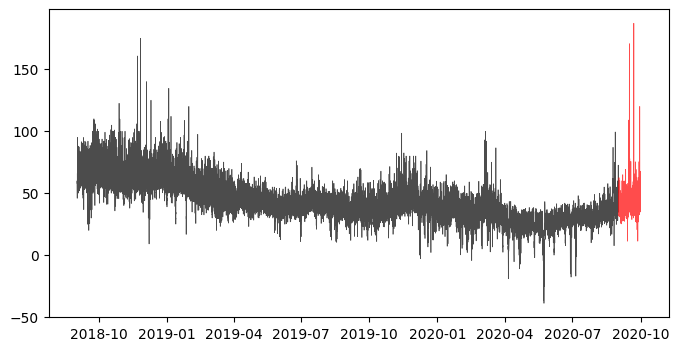

In [5]:
fig, axes = plt.subplots(1,1, figsize=(8, 4))

axes.plot(training_data.index, 
         training_data['price_day_ahead_filled'], 
         linewidth=0.5, alpha=0.7, color='black')
axes.plot(validation_data.index, 
         validation_data['price_day_ahead_filled'], 
         linewidth=0.5, alpha=0.7, color='red')

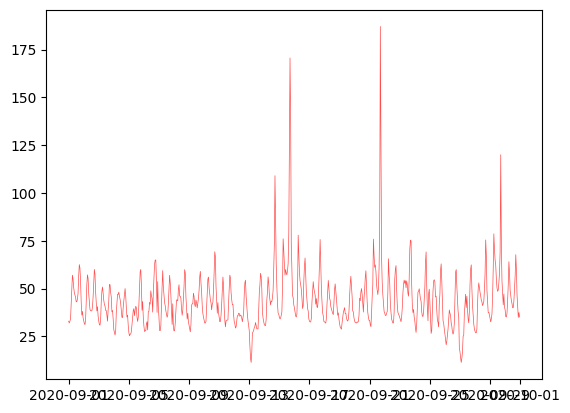

In [6]:
plt.plot(validation_data.index, 
         validation_data['price_day_ahead_filled'], 
         linewidth=0.5, alpha=0.7, color='red')

In [7]:
np.mean(training_data['price_day_ahead_filled']), np.std(training_data['price_day_ahead_filled'])

(np.float64(41.90260657318465), np.float64(16.396000943525074))

Text(0.5, 0, 'Spot-Price £/MWhr')

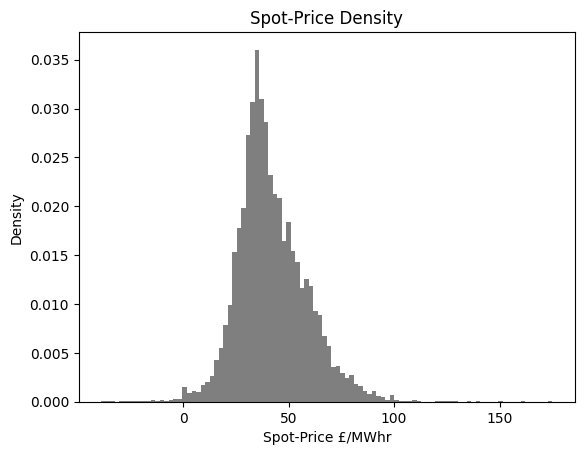

In [8]:
plt.hist(training_data['GB_GBN_price_day_ahead'], 100, density=True, 
         color='black', alpha=0.5);
plt.title("Spot-Price Density")
plt.ylabel("Density")
plt.xlabel("Spot-Price £/MWhr")

mean log-vol: 2.1505284352744622
SD log-vol: 0.317153663426865


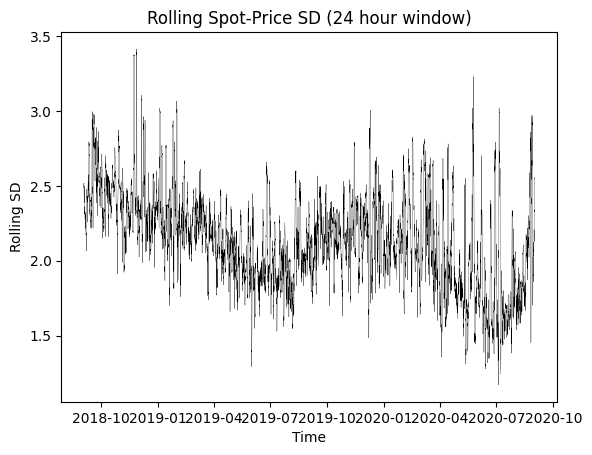

In [9]:
rolling_log_vol = np.log(training_data['GB_GBN_price_day_ahead'].rolling(24).std())

plt.plot(training_data.index, 
         np.log(training_data['GB_GBN_price_day_ahead'].rolling(24).std()),
         color='black', linewidth=0.2)
plt.title("Rolling Spot-Price SD (24 hour window)")
plt.ylabel("Rolling SD")
plt.xlabel("Time")
print("mean log-vol:", np.mean(rolling_log_vol))
print("SD log-vol:", np.std(rolling_log_vol))

mean log-vol: 2.1505284352744622
SD log-vol: 0.317153663426865


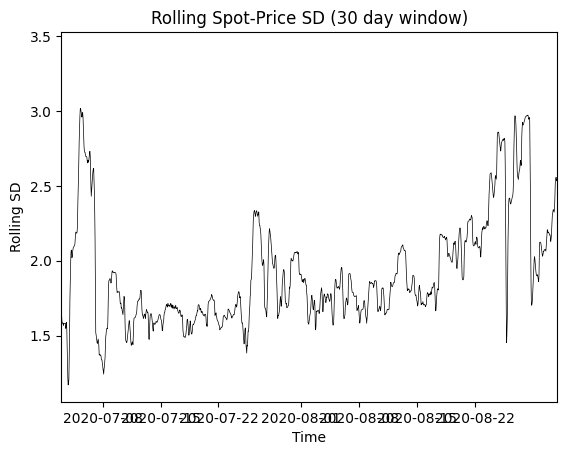

In [10]:
rolling_log_vol = np.log(training_data['GB_GBN_price_day_ahead'].rolling(24).std())

plt.plot(training_data.index, 
         np.log(training_data['GB_GBN_price_day_ahead'].rolling(24).std()),
         color='black', linewidth=0.5)
plt.xlim([training_data.index[-2*30*24], training_data.index[-1]])
plt.title("Rolling Spot-Price SD (30 day window)")
plt.ylabel("Rolling SD")
plt.xlabel("Time")

print("mean log-vol:", np.mean(rolling_log_vol))
print("SD log-vol:", np.std(rolling_log_vol))

In [11]:
# Stan is 1-indexed, so add 1
day_idx   = (training_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx  = (training_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

day_idx_fore = (validation_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx_fore = (validation_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

# Fit model

## Run Inference

In [12]:
filename = "./Posterior/oujp_parameters.csv"
oujp_post = pd.read_csv(filename)

In [80]:
# Stan is 1-indexed, so add 1
day_idx   = (training_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx  = (training_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

day_idx_fore = (validation_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx_fore = (validation_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

time_year_obs_data = np.arange(0, training_data.shape[0]) / 8760
time_year_val_data = np.arange(training_data.shape[0], training_data.shape[0] + validation_data.shape[0]) / 8760

stan_training_X_data = pd.DataFrame({
    'time_year': time_year_obs_data,
    'hour_indicator': hour_idx,
    'day_indicator': day_idx
    })

stan_validation_X_data = pd.DataFrame({
    'time_year': time_year_val_data,
    'hour_indicator': hour_idx_fore,
    'day_indicator': day_idx_fore
})

In [81]:
stan_data = {
    # -- training data
    'T': len(training_data['price_day_ahead_filled']),
    'y': training_data['price_day_ahead_filled'].to_numpy(),
    'time_year': stan_training_X_data['time_year'].to_numpy(),
    'day_of_week_index': stan_training_X_data['day_indicator'].to_numpy(),
    'hour_index': stan_training_X_data['hour_indicator'].to_numpy(),
    'dt': 1,

    # -- validation data

    # -- Spot price OU
    'theta_mean': 2,
    'theta_sd': 2,

    # -- Volatility OU
    'theta_v_mean': 0,
    'theta_v_sd': 1,
    'mu_v_mean': np.mean(training_data['GB_GBN_price_day_ahead'].rolling(24).std()),
    'mu_v_sd': 0.1,
    'sigma_v_mean': np.std(training_data['GB_GBN_price_day_ahead'].rolling(24).std()),
    'sigma_v_sd': 0.1,

    # Poisson Jump
    'p_jump_alpha': 1,
    'p_jump_beta': 10,

    # -- jump-size mean
    'mu_jump_mean': 0,
    'mu_jump_sd': 1, 

    # -- jump-size variance 
    'sigma_jump_shape': 5**2 / 1,
    'sigma_jump_rate':  5 / 1,

    # deterministic mean function
    'overall_mean_mu': np.mean(training_data['price_day_ahead_filled']),
    'overall_mean_sd': 1,
    'yearly_trend_mu': 0, 
    'yearly_trend_sd': 10,

    # -- fix parameters
    'p_jump': np.mean( oujp_post['p_jump'] )
}

In [ ]:
stan_model_file = Path('./stan_files/levels_mf_ou_svjp.stan')
model_code = stan_model_file.read_text()
posterior = stan.build(model_code, data=stan_data)

n_chains = 4
n_burnin = 500
n_posterior = 500

fit = posterior.sample(num_chains=n_chains, num_samples=n_posterior, num_warmup=n_burnin)

## Plot Posterior Chains

In [ ]:
plot_trace_and_densities(fit, ['overall_mean', 'yearly_trend', 'theta'], n_posterior, n_chains)

In [ ]:
plot_trace_and_densities(fit, ['fourier_coef'], n_posterior, n_chains)

In [ ]:
plot_trace_and_densities(fit, ['mu_v', 'theta_v', 'sigma_v'], n_posterior, n_chains)

In [ ]:
plot_trace_and_densities(fit, ['mu_jump', 'sigma_jump'], n_posterior, n_chains)

In [ ]:
plot_trace_and_densities(fit, ['day_coef_raw'], n_posterior, n_chains) 

In [ ]:
plot_trace_and_densities(fit, ['hour_coef_raw'], n_posterior, n_chains)

## Save Posterior Output

Sometimes a chain must be removed as it shows signs on non-convergence

In [ ]:
chain_to_remove = 0 # second chain (0-based)

remove_chain = False
save_output = False

if remove_chain:
    # Save posterior draws to a dataframe and remove the 2nd chain (chain index 1, 0-based)
    fit_df = fit.to_frame()
    fit_df['p_jump'] = stan_data['p_jump']
    # number of chains used (use existing n_chains if present)
    try:
        n_chains_local = n_chains
    except NameError:
        n_chains_local = 3



    # Handle common index layouts; default to positional removal if uncertain
    if isinstance(fit_df.index, pd.MultiIndex) and 'chain' in fit_df.index.names:
        # chains often 1-indexed in MultiIndex
        chain_labels = fit_df.index.get_level_values('chain')
        label_to_remove = chain_to_remove + 1 if (chain_labels.min() == 1) else chain_to_remove
        fit_df_no_chain = fit_df.loc[chain_labels != label_to_remove].reset_index(drop=True)
    else:
        idx = np.arange(len(fit_df))
        mask = (idx % n_chains_local) != chain_to_remove
        fit_df_no_chain = fit_df.iloc[mask].reset_index(drop=True)
        
    if save_output:
        param_names = ['lp__', 'overall_mean', 'yearly_trend', 'theta', 'mu_v', 'theta_v', 'sigma_v', 'mu_jump', 'sigma_jump']
        for i in range(1,7):
            param_names.append("day_coef_raw." + str(i))
        for i in range(1,24):
            param_names.append("hour_coef_raw." + str(i))
        for i in range(1,3):
            for j in range(1,4):
                param_names.append("fourier_coef." + str(i) + '.' + str(j))
            
        print(param_names)
        post_to_save = fit_df_no_chain[param_names]
        post_to_save.to_csv("./Posterior/ou_svjp_fix_pjump_parameters.csv")

    # fit_df contains all draws; fit_df_no_chain2 has the second chain removed

In [ ]:
# Save the posterior parameter draws
save_output = False

if save_output:
    fit_df = fit.to_frame()
    fit_df['p_jump'] = stan_data['p_jump']
    param_names = ['lp__', 'overall_mean', 'yearly_trend', 'theta', 'mu_jump', 'sigma_jump', 'sigma_v', 'theta_v', 'mu_v'] # 'p_jump'
    for i in range(1,7):
        param_names.append("day_coef_raw." + str(i))
    for i in range(1,24):
        param_names.append("hour_coef_raw." + str(i))
    for i in range(1,3):
        for j in range(1,4):
            param_names.append("fourier_coef." + str(i) + "." + str(j))
        
    print(param_names)
    post_to_save = fit_df[param_names]
    post_to_save.to_csv("./Posterior/ou_svjp_fix_pjump_parameters.csv")

    

# Posterior Predictive Plots

In [13]:
# Include the final observation of the training data in the validation data, so that it can be conditioned upon
day_idx   = (training_data.index.day_of_week).to_numpy(dtype=int)  # 0-6
hour_idx  = (training_data.index.hour ).to_numpy(dtype=int)   # 0-23

day_idx_fore = (validation_data.index.day_of_week).to_numpy(dtype=int)  # 0-6
hour_idx_fore = (validation_data.index.hour).to_numpy(dtype=int)   # 0-23

day_idx_fore = np.insert(day_idx_fore, 0, day_idx[-1])
hour_idx_fore = np.insert(hour_idx_fore, 0, hour_idx[-1])

long_idx = pd.date_range(
                        start="2020-09-01",
                        end="2021-09-01",
                        freq="h")
day_idx_long_fore = long_idx.day_of_week.to_numpy(dtype=int)  # 0-6
hour_idx_long_fore = long_idx.hour.to_numpy(dtype=int)   # 0-23

time_year_obs_data = np.arange(0, training_data.shape[0]) / 8760
time_year_val_data = np.arange(training_data.shape[0]-1, training_data.shape[0] + validation_data.shape[0]) / 8760
time_year_long_val_data = np.arange(training_data.shape[0], training_data.shape[0] + len(long_idx)) / 8760

training_X_data = pd.DataFrame({
    'time_year': time_year_obs_data,
    'hour_indicator': hour_idx,
    'day_indicator': day_idx
    })

validation_X_data = pd.DataFrame({
    'time': pd.date_range(training_data.index[-1], validation_data.index[-1], freq="h"),
    'price_day_ahead_filled': np.insert(validation_data['price_day_ahead_filled'].to_numpy(), 0, training_data['price_day_ahead_filled'].iloc[-1]),
    'time_year': time_year_val_data,
    'hour_indicator': hour_idx_fore,
    'day_indicator': day_idx_fore
})

long_validation_X_data = pd.DataFrame({
    'time': pd.date_range(
                        start="2020-09-01",
                        end="2021-09-01",
                        freq="h"),
    'time_year': time_year_long_val_data,
    'hour_indicator': hour_idx_long_fore,
    'day_indicator': day_idx_long_fore
})

In [14]:
filename = './Posterior/ou_svjp_fix_pjump_parameters.csv'
post_df = pd.read_csv(filename)
post_df['p_jump'] = np.mean( oujp_post['p_jump'] )

## Stochastic Volatility

In [158]:
log_volatility_pred = posterior_latent_process(post_df, training_data.shape[0])
vol_pred_qnts = np.quantile(np.exp(log_volatility_pred), [0.005, 0.995], axis=0)
log_vol_pred_qnts = np.quantile(log_volatility_pred, [0.005, 0.995], axis=0)

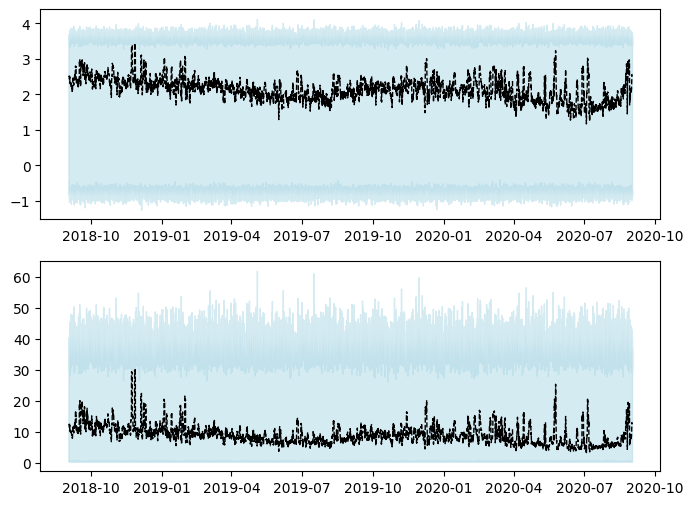

In [159]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                 log_vol_pred_qnts[0], 
                 log_vol_pred_qnts[1], 
                 color='lightblue', alpha=0.5)
axes[0].plot(training_data.index, 
         np.log(training_data['GB_GBN_price_day_ahead'].rolling(24).std()), 
         color='black', linestyle='--', linewidth=1)

axes[1].fill_between(training_data.index, 
                 vol_pred_qnts[0], 
                 vol_pred_qnts[1], 
                 color='lightblue', alpha=0.5)
axes[1].plot(training_data.index, 
         training_data['GB_GBN_price_day_ahead'].rolling(24).std(), 
         color='black', linestyle='--', linewidth=1)

Text(0.5, 0, 'V_T')

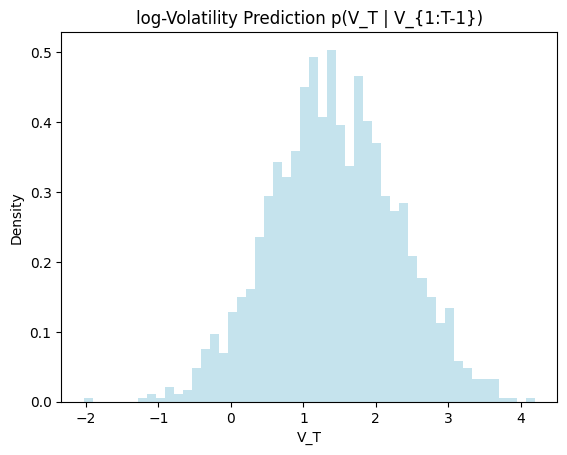

In [160]:
plt.hist(log_volatility_pred[:,-1], 50, density=True, 
         color='lightblue', alpha=0.7);
plt.title("log-Volatility Prediction p(V_T | V_{1:T-1})")
plt.ylabel("Density")
plt.xlabel("V_T")

## Observed Process

In [15]:
one_step_exp, one_step_pred = posterior_one_step_predictive(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)
one_step_pred_qnts = np.quantile(one_step_pred, [0.005, 0.25, 0.75, 0.995], axis=0)

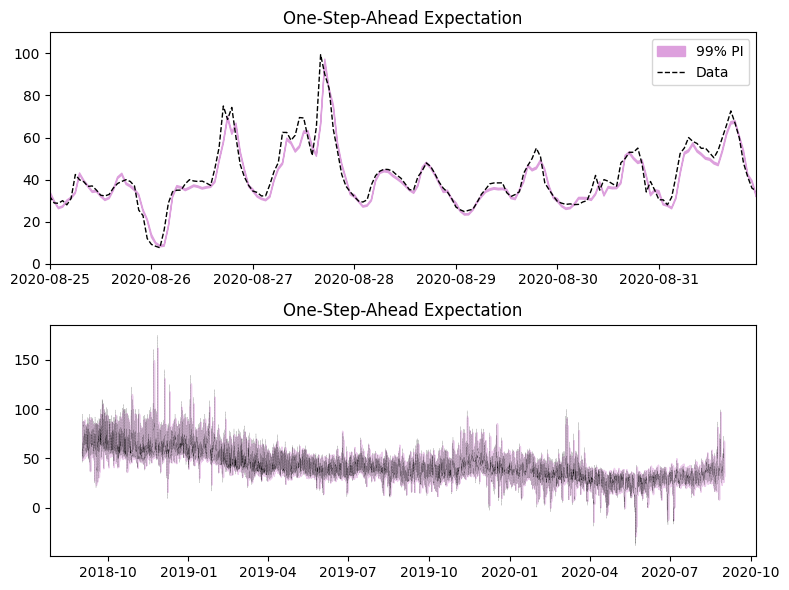

In [ ]:
one_step_expected_qnts = np.quantile(one_step_exp, [0.005, 0.995], axis=0)

fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                one_step_expected_qnts[0], 
                one_step_expected_qnts[1], 
                alpha=1.0, color='plum', label="99% PI")
axes[0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label='Data')
axes[0].set_xlim([training_data.index[-7*24], training_data.index[-1]])
axes[0].set_ylim([0, 110])
axes[0].set_title("One-Step-Ahead Expectation")
axes[0].legend()

axes[1].fill_between(training_data.index, 
                one_step_expected_qnts[0], 
                one_step_expected_qnts[1], 
                alpha=0.5, color='plum')
axes[1].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[1].set_title("One-Step-Ahead Expectation")

plt.tight_layout()
plt.show()

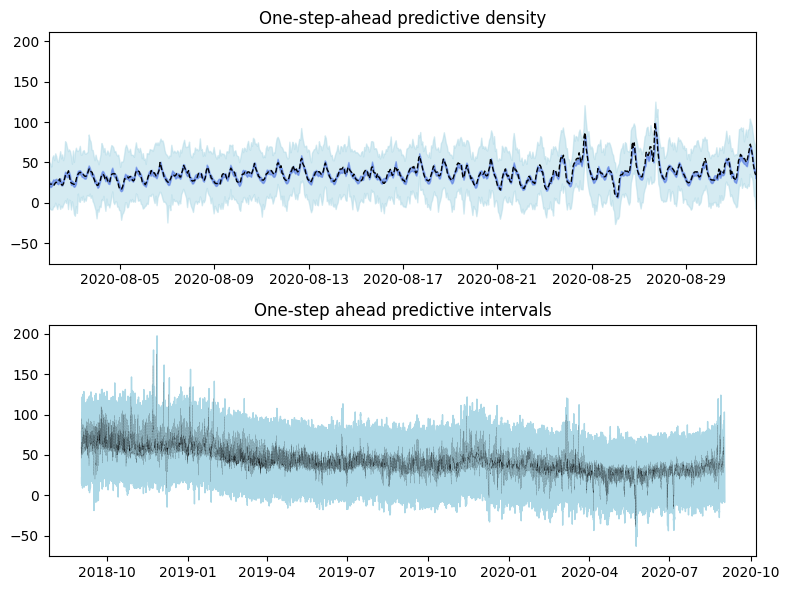

In [202]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                one_step_pred_qnts[0], 
                one_step_pred_qnts[3], 
                alpha=0.5, color='lightblue')
axes[0].fill_between(training_data.index, 
                one_step_pred_qnts[1], 
                one_step_pred_qnts[2], 
                alpha=0.5, color='royalblue')
axes[0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0)
axes[0].set_xlim([training_data.index[-30*24], training_data.index[-1]])
axes[0].set_title("One-step-ahead predictive density")

axes[1].fill_between(training_data.index, 
                one_step_pred_qnts[0], 
                one_step_pred_qnts[3], 
                alpha=1.0, color='lightblue')
axes[1].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[1].set_title("One-step ahead predictive intervals")

plt.tight_layout()
plt.show()

In [ ]:
post_pred = posterior_predictive(post_df, training_data['price_day_ahead_filled'].iloc[0], training_X_data)
post_pred_qnts = np.quantile(post_pred, [0.025, 0.25, 0.75, 0.975], axis=0)

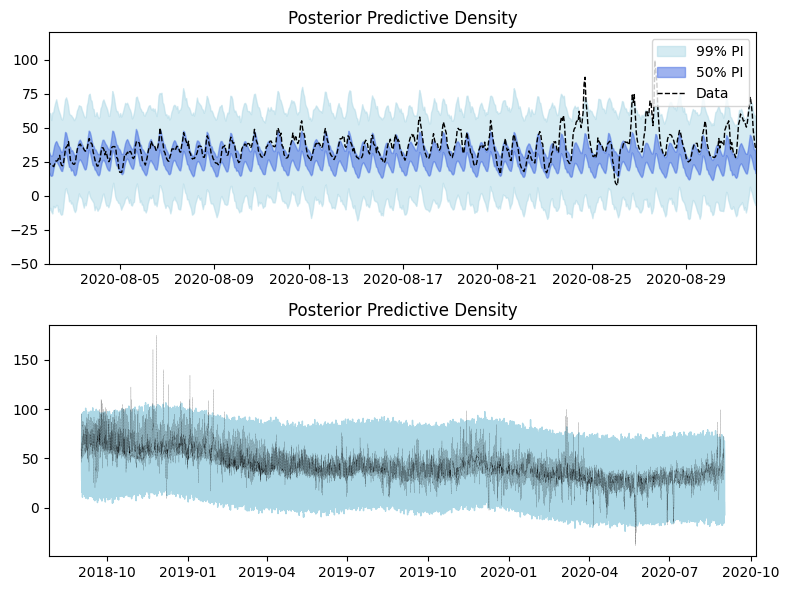

In [201]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                post_pred_qnts[0], 
                post_pred_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[0].fill_between(training_data.index, 
                post_pred_qnts[1], 
                post_pred_qnts[2], 
                alpha=0.5, color='royalblue', label="50% PI")
axes[0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[0].set_xlim([training_data.index[-30*24], training_data.index[-1]])
axes[0].set_ylim([-50,120])
axes[0].set_title("Posterior Predictive Density")
axes[0].legend()

axes[1].fill_between(training_data.index, 
                post_pred_qnts[0], 
                post_pred_qnts[3], 
                alpha=1.0, color='lightblue')
axes[1].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[1].set_title("Posterior Predictive Density")

plt.tight_layout()
plt.show()

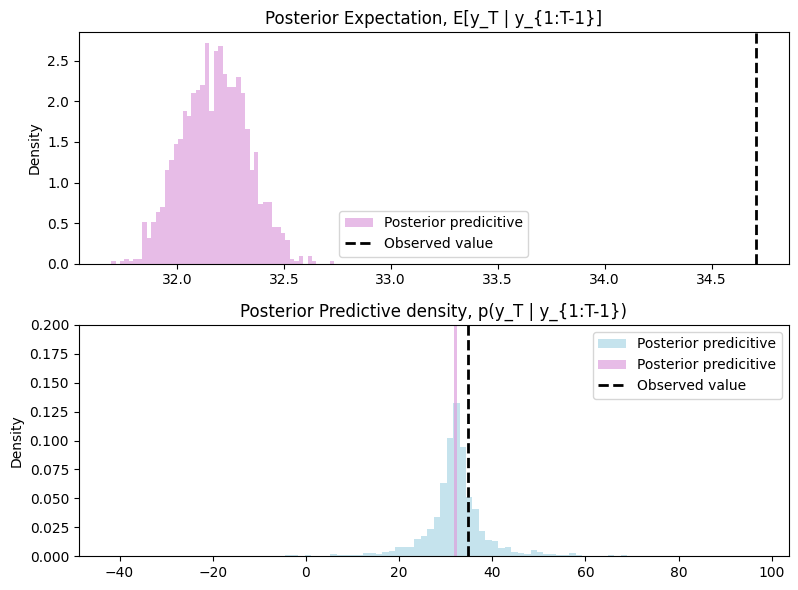

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].hist(one_step_exp[:,-1], 50, density=True,
         color='plum', alpha=0.7, label="Posterior predicitive")
axes[0].axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="Observed value")
axes[0].set_ylabel("Density")
axes[0].set_title("Posterior Expectation, E[y_T | y_{1:T-1}]")
# axes[0].set_xlim(min(y_expected_df.iloc[:,-1]), max(y_expected_df.iloc[:,-1]))
axes[0].legend()

axes[1].hist(one_step_pred[:,-1], 100, density=True, 
             color='lightblue', alpha=0.7, label="Posterior predicitive");
axes[1].hist(one_step_exp[:,-1], 100, density=True, 
             color='plum', alpha=0.7, label="Posterior predicitive");
axes[1].axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="Observed value")
axes[1].set_ylim([0, 0.2])
axes[1].set_ylabel("Density")
axes[1].set_title("Posterior Predictive density, p(y_T | y_{1:T-1})")
axes[1].legend()

plt.tight_layout()


In [16]:
post_pred_fore = posterior_predictive(post_df, validation_data['price_day_ahead_filled'].iloc[0], validation_X_data)
post_pred_fore_qnts = np.quantile(post_pred_fore, [0.025, 0.25, 0.75, 0.975], axis=0)

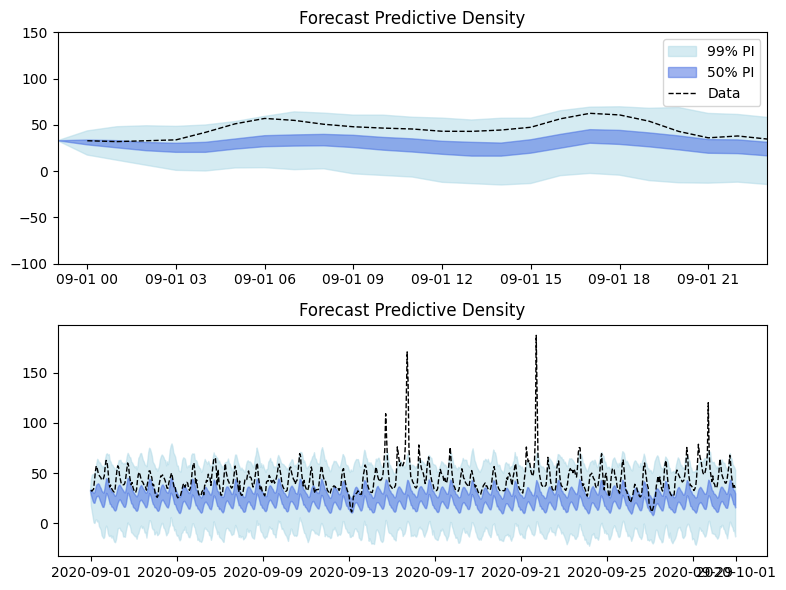

In [178]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[0], 
                post_pred_fore_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[0].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[1], 
                post_pred_fore_qnts[2], 
                alpha=0.5, color='royalblue', label="50% PI")
axes[0].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[0].set_xlim([validation_X_data['time'][0], validation_X_data['time'][24]])
axes[0].set_ylim([-100,150])
axes[0].set_title("Forecast Predictive Density")
axes[0].legend()

axes[1].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[0], 
                post_pred_fore_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[1].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[1], 
                post_pred_fore_qnts[2], 
                alpha=0.5, color='royalblue', label="99% PI")
axes[1].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[1].set_title("Forecast Predictive Density")

plt.tight_layout()
plt.show()

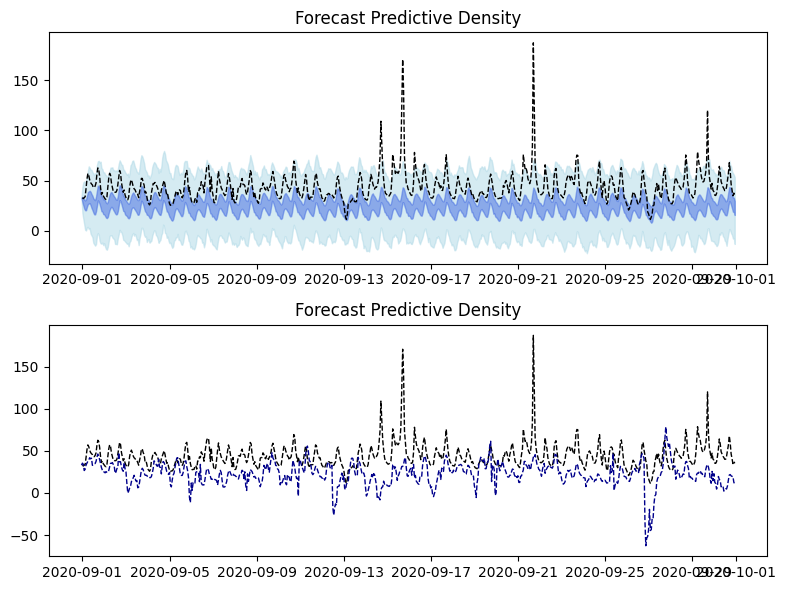

In [200]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[0], 
                post_pred_fore_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[0].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[1], 
                post_pred_fore_qnts[2], 
                alpha=0.5, color='royalblue', label="99% PI")
axes[0].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[0].set_title("Forecast Predictive Density")


"""axes[1].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[0], 
                post_pred_fore_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[1].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[1], 
                post_pred_fore_qnts[2], 
                alpha=0.5, color='royalblue', label="99% PI")"""
axes[1].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")

axes[1].plot(validation_X_data['time'], post_pred_fore[0], 
             color='darkblue', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[1].set_title("Forecast Predictive Density")

plt.tight_layout()
plt.show()

In [ ]:
post_pred_long_fore = posterior_predictive(post_df, validation_data['price_day_ahead_filled'].iloc[0], long_validation_X_data)
post_pred_long_fore_qnts = np.quantile(post_pred_long_fore, [0.005, 0.25, 0.75, 0.995], axis=0)

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(long_validation_X_data.time, 
                post_pred_long_fore_qnts[0], 
                post_pred_long_fore_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[0].fill_between(long_validation_X_data.time, 
                post_pred_long_fore_qnts[1], 
                post_pred_long_fore_qnts[2], 
                alpha=0.5, color='royalblue', label="50% PI")
# axes[0].set_xlim([long_validation_X_data.time[0], long_validation_X_data.time.iloc[-1]])
axes[0].set_ylim([-100,175])
axes[0].set_title("Forecast Predictive Density")
axes[0].legend()

axes[1].fill_between(long_validation_X_data.time, 
                post_pred_long_fore_qnts[0], 
                post_pred_long_fore_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[1].fill_between(long_validation_X_data.time, 
                post_pred_long_fore_qnts[1], 
                post_pred_long_fore_qnts[2], 
                alpha=0.5, color='royalblue', label="99% PI")
axes[1].set_title("Forecast Predictive Density")

plt.tight_layout()
plt.show()

## Posterior Predictive Error

In [ ]:
n_post = one_step_exp.shape[0]
posterior_maee = np.empty(n_post)
posterior_rmsee = np.empty(n_post)
posterior_mape = np.empty(n_post)
posterior_rmspe = np.empty(n_post)

for ind in range(n_post):
    maee = np.mean(abs(one_step_exp[ind, :] - training_data['GB_GBN_price_day_ahead']))
    posterior_maee[ind] = maee
    rmsee = np.mean( (one_step_exp[ind, :] - training_data['GB_GBN_price_day_ahead'])**2)
    posterior_rmsee[ind] = rmsee

for ind in range(n_post):
    mape = np.mean(abs(one_step_pred[ind, :] - training_data['GB_GBN_price_day_ahead']))
    posterior_mape[ind] = mape
    rmspe = np.mean( (one_step_pred[ind, :] - training_data['GB_GBN_price_day_ahead'])**2)
    posterior_rmspe[ind] = rmspe

fig, axes = plt.subplots(2,2, figsize=(8, 5))

axes[0,0].hist(posterior_maee, 100, density=True, 
               alpha=0.7, color='lightblue')
axes[0,0].set_title("MAEE Posterior")
axes[0,1].hist(posterior_rmsee, bins=100, density=True, 
               alpha=0.7, color='lightblue')
axes[0,1].set_title("RSMEE Posterior")

axes[1,0].hist(posterior_mape, 100, density=True, 
               alpha=0.7, color='lightblue')
axes[1,0].set_title("MAPE Posterior")
axes[1,1].hist(posterior_rmspe, bins=100, density=True, 
               alpha=0.7, color='lightblue')
axes[1,1].set_title("RSMPE Posterior")

plt.tight_layout()
plt.show()

# Model Fit and Predicitive Statistics

In [21]:
def posterior_loglik(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame, predictive=False):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    log_lik_matrix = np.empty((n_post, n_data-1))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        alpha = np.exp(-param_vals['theta'])
        
        det_mean = mean_function(param_vals, X_data)
        # simulate the latent process
        log_vol, pred_sample = sample_process_predictive(param_vals, y_data[0], X_data)
        # expected value
        if predictive:
            mean = det_mean[1:] + alpha * (pred_sample[:(n_data-1)] - det_mean[:(n_data-1)])
        else:
            mean = det_mean[1:] + alpha * (y_data[:(n_data-1)] - det_mean[:(n_data-1)])

        # calculate the volatility
        sd = np.exp(log_vol[1:]) * np.sqrt( (1 - alpha*alpha) / (2*param_vals['theta']) )
        
        log_lik_matrix[post_ind, :] = norm.logpdf(y_data[1:], loc=mean, scale=sd)

    return log_lik_matrix

def log_predictive_score_from_loglik(loglik_mat: np.array):
    n_post = loglik_mat.shape[0]

    return logsumexp(loglik_mat, axis=0) - np.log(n_post)

def log_predictive_score(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    loglik_matrix = posterior_loglik(post, y_data, X_data, predictive=True)

    return log_predictive_score_from_loglik(loglik_matrix)

def waic_from_loglik(log_lik_matrix: np.array):  
    n_post = log_lik_matrix.shape[0]
    # sum of the logged mean likelihood (expected density) per observation
    log_expected_ll = logsumexp(log_lik_matrix, axis=0) - np.log(n_post) 
    mean_log_expected_ll = log_expected_ll.sum()

    # variance of log-likliehood per observation
    var_ll = np.var(log_lik_matrix, axis=0, ddof=1) 

    p_waic = 2 * (var_ll - log_expected_ll).sum()

    return p_waic
    
def waic(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    log_lik_matrix = posterior_loglik(post, y_data, X_data, predictive=False)

    return waic_from_loglik(log_lik_matrix)

def cts_ranked_probability_score_from_pred(pred: np.array, y_data: np.array):
    n_post = pred.shape[0]
    n_data = y_data.shape[0]

    scores = np.empty(n_data - 1)

    for data_ind in range(1, n_data):
        random_ind = np.random.randint(0, n_post, size=(2, n_post))
        abs_data_diff = abs( pred[:, data_ind] - y_data[data_ind] ).mean()
        abs_rand_diff = abs( pred[random_ind[0], data_ind] - pred[random_ind[1], data_ind] ).sum() / ( n_post*(n_post -1) )
        scores[data_ind-1] = abs_data_diff - 0.5 * abs_rand_diff

    return scores

def cts_ranked_probability_score(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    latent_sample, pred_sample = predictive_sample(post_df, y_data, training_X_data)
    return cts_ranked_probability_score_from_pred(pred_sample, y_data)

In [ ]:
obs_loglik_matrix = posterior_loglik(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data, predictive=False)
np.savetxt("./posterior_files/levels_mf3_ou_svjp_loglik.csv", ll_mat, delimiter=",")

In [ ]:
loglik = logsumexp(obs_loglik_matrix, axis=1)
print("mean ll:", np.mean(loglik)) # 7.159897229196207
print("SD ll:", np.std(loglik)) # 0.013326094792163883

mean ll: 7.159897229196207
SD ll: 0.013326094792163883


In [ ]:
p_waic = waic_from_loglik(obs_loglik_matrix)
print("WAIC:", p_waic) # 73667310.08639464
print("log10 WIAC", np.log10(p_waic)) # 7.867274812165681

WAIC: 73667310.08639464
log10 WIAC 7.867274812165681


In [ ]:
log_score = log_predictive_score(post_df, validation_X_data['price_day_ahead_filled'].to_numpy(), validation_X_data)
print("mean LS:", np.mean(log_score)) # -4.771698616675047
print("range LS:", min(log_score), max(log_score)) # -13.805067802565532 -2.149180682596966

mean LS: -4.771698616675047
range LS: -13.805067802565532 -2.149180682596966


In [ ]:
# k = [hour] + [day] + [fourier] + [mean trend] + [stochastic]
number_of_parameters = 23 + 6 + 6 + 2 + 6
loglik = logsumexp(obs_loglik_matrix, axis=0)

BIC = number_of_parameters * np.log(training_data.shape[0]-1) - 2 * max(loglik)
print("BIC:", BIC) # 409.186140299733

BIC: 409.186140299733


In [ ]:
from arviz import ess
from arviz import rhat

post_ess_df = post_df.drop(columns=["Unnamed: 0", "lp__", "p_jump"])
post_ess_arr = post_ess_df.to_numpy()
post_ess_array = post_ess_arr.reshape(500, 3, post_ess_arr.shape[1])

effective_sample_size = ess(post_ess_array, chain_axis=1, draw_axis=0)
print("EES:", min(effective_sample_size), max(effective_sample_size))


EES: 244.95189815554534 2930.377474011734


In [64]:
post_ess_df.columns[effective_sample_size<500] # 'theta_v', 'sigma_v', 'hour_coef_raw.13'
effective_sample_size[effective_sample_size<500]

array([244.95189816, 247.90269843, 492.56186159])

In [60]:
rhat(post_ess_array, chain_axis=1, draw_axis=0) < 1.05

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [ ]:
cprs_within_sample = cts_ranked_probability_score_from_pred(one_step_pred, training_data['price_day_ahead_filled'].to_numpy())
cprs_outof_sample = cts_ranked_probability_score_from_pred(post_pred_fore, validation_X_data['price_day_ahead_filled'])

print("Mean within-sample one-step-ahead:", cprs_within_sample.mean()) # 6.101683377103931
print("Mean out-of-sample predicted:", cprs_outof_sample.mean()) # 21.41660608418405

Mean within-sample one-step-ahead: 6.101683377103931
Mean out-of-sample predicted: 21.41660608418405


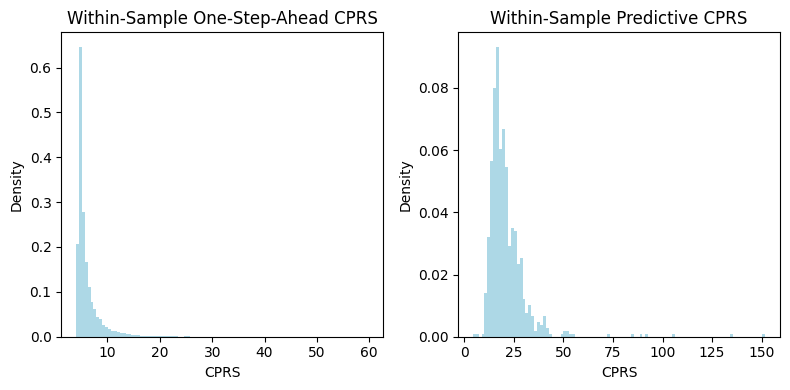

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(8, 4))

axes[0].hist(cprs_within_sample, 100, density=True, 
             color="lightblue")
axes[0].set_xlabel("CPRS")
axes[0].set_ylabel("Density")
axes[0].set_title("Within-Sample One-Step-Ahead CPRS")

axes[1].hist(cprs_outof_sample, 100, density=True, 
             color="lightblue");
axes[1].set_xlabel("CPRS")
axes[1].set_ylabel("Density")
axes[1].set_title("Within-Sample Predictive CPRS")

plt.tight_layout()

In [84]:
prior_df = pd.DataFrame({
    'mu_v': np.random.normal(loc=stan_data['mu_v_mean'], scale=stan_data['mu_v_sd'], size=5000),
    'theta_v': np.random.normal(loc=stan_data['theta_v_mean'], scale=stan_data['theta_v_sd'], size=5000),
    'sigma_v': np.random.normal(loc=stan_data['sigma_v_mean'], scale=stan_data['sigma_v_sd'], size=5000)
})

In [103]:
def plot_trace_and_densities_dataframe(fit: pd.DataFrame, param_names, prior = None):
    param_names_copy = param_names
    total_param_number = len(param_names)
    for param in param_names:
        if param not in fit.columns:
            print(param, "not present.")
            param_names_copy.remove(param)

    fig, axes = plt.subplots(total_param_number, 2, figsize=(8, 1.5*total_param_number))

    fig_index = 0
    for param in param_names_copy:
        posterior_draws = fit[param]
        axes[fig_index, 0].plot(posterior_draws, alpha=0.7)
        axes[fig_index, 1].hist(posterior_draws, 100, alpha=0.7)
        axes[fig_index, 0].set_title(param)
        axes[fig_index, 1].set_title(param)
        if (prior is not None) and (param in prior.columns):
            kde = gaussian_kde(prior[param].to_numpy())
            grid = np.linspace(min(prior[param]), max(prior[param]), 500)
            axes[fig_index, 1].plot(grid, kde(grid), color="green")
        fig_index += 1
    plt.tight_layout()
    plt.show()

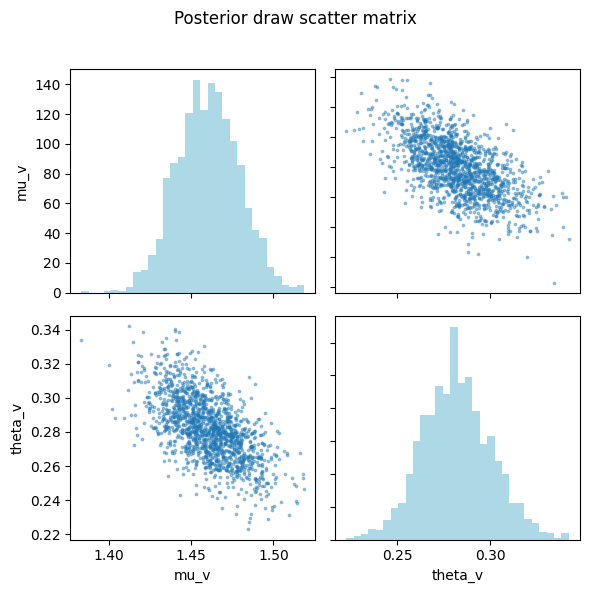

In [72]:
plot_posterior_scatter_matrix_dataframe(post_df, ['mu_v', 'theta_v'])

# Blog plots

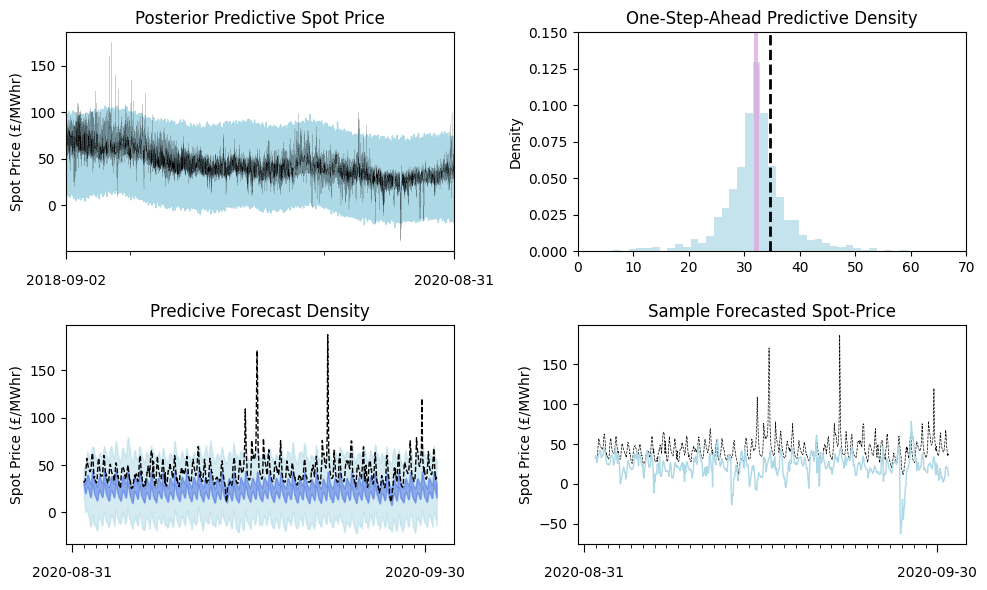

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,6), sharex=False)

axes[0,0].fill_between(training_data.index, 
                post_pred_qnts[0], 
                post_pred_qnts[3], 
                alpha=1.0, color='lightblue')
axes[0,0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[0,0].set_title("Posterior Predictive Spot Price")
axes[0,0].set_ylabel("Spot Price (£/MWhr)")

# Show only the first and final day labels at their 00:00 observations
first_tick = training_data.index[0]
last_tick = training_data.index[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='YE'
)

axes[0,0].set_xlim(first_tick, last_tick)
axes[0,0].set_xticks([first_day_tick, last_day_tick])
axes[0,0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[0,0].set_xticks(intermediate_day_ticks, minor=True)
axes[0,0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[0,0].tick_params(axis="x", which="major", length=6, pad=10)
axes[0,0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)


axes[0,1].hist(one_step_pred[:,-1], 200, density=True, 
             color='lightblue', alpha=0.7, label="p()");
axes[0,1].hist(one_step_exp[:,-1], 100, density=True, 
             color='plum', alpha=0.7, label="E()");
axes[0,1].axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="y")
axes[0,1].set_ylim([0, 0.15])
axes[0,1].set_xlim([0,70])
axes[0,1].set_ylabel("Density")
axes[0,1].set_title("One-Step-Ahead Predictive Density")

axes[1,0].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[0], 
                post_pred_fore_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[1,0].fill_between(validation_X_data['time'], 
                post_pred_fore_qnts[1], 
                post_pred_fore_qnts[2], 
                alpha=0.5, color='royalblue', label="99% PI")
axes[1,0].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[1,0].set_title("Predicive Forecast Density")
axes[1,0].set_ylabel("Spot Price (£/MWhr)")

first_tick = validation_X_data['time'].iloc[0]
last_tick = validation_X_data['time'].iloc[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='D'
)

axes[1,0].set_xticks([first_day_tick, last_day_tick])
axes[1,0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1,0].set_xticks(intermediate_day_ticks, minor=True)
axes[1,0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1,0].tick_params(axis="x", which="major", length=6, pad=10)
axes[1,0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)

axes[1,1].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=0.5, linestyle='--', alpha=1.0, )
axes[1,1].plot(validation_X_data['time'], post_pred_fore[0], 
             color='lightblue', linewidth=1.0, linestyle='-', alpha=1.0,)
axes[1,1].set_title("Sample Forecasted Spot-Price")
axes[1,1].set_ylabel("Spot Price (£/MWhr)")

axes[1,1].set_xticks([first_day_tick, last_day_tick])
axes[1,1].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1,1].set_xticks(intermediate_day_ticks, minor=True)
axes[1,1].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1,1].tick_params(axis="x", which="major", length=6, pad=10)
axes[1,1].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)


plt.tight_layout()


In [261]:
def mean_function_yearly_trend(parameter_values: pd.Series, X_data: pd.DataFrame):
    day_coef_index = [i for i in range(parameter_values.shape[0]) if 'day_coef' in parameter_values.keys()[i]]
    hour_coef_index = [i for i in range(parameter_values.shape[0]) if 'hour_coef' in parameter_values.keys()[i]]

    day_coef_vals = np.insert(parameter_values.iloc[day_coef_index].to_numpy(), 0, 0.0)
    hour_coef_vals = np.insert(parameter_values.iloc[hour_coef_index].to_numpy(), 0 , 0.0)

    # f_1
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']]
    # f_2
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] + parameter_values['fourier_coef.1'] * np.cos(2*np.pi*X_data['time_year']) + parameter_values['fourier_coef.2'] * np.sin(2*np.pi*X_data['time_year'])
    # f_3
    mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year']
    for k in range(1,4):
        a1 = parameter_values['fourier_coef.1.' + str(k)]
        a2 = parameter_values['fourier_coef.2.' + str(k)]
        mean += +  a1* np.cos(2*np.pi*k*X_data['time_year']) + a2 * np.sin(2*np.pi*k*X_data['time_year'])
    return mean.to_numpy()

def posterior_mean_function_yearly_trend(post: pd.DataFrame, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = X_data.shape[0]

    post_mean_fn = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, ]
        post_mean_fn[post_ind,] = mean_function_yearly_trend(param_vals, X_data)

    return post_mean_fn

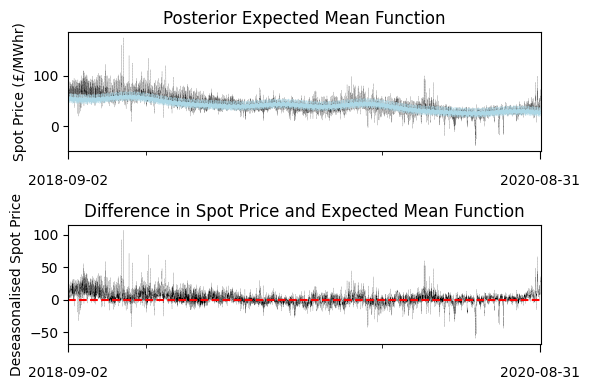

In [ ]:
posterior_mean = posterior_det_mean(post_df, training_X_data)
posterior_mean_qnts = np.quantile(posterior_mean, [0.005, 0.5, 0.995], axis=0)

fig, axes = plt.subplots(2,1, figsize=(6,4), sharex=False)

axes[0].plot(training_data.index, 
         training_data['price_day_ahead_filled'], 
         linestyle='--', color='black', linewidth=0.1)
axes[0].plot(training_data.index, 
         posterior_mean_qnts[1], 
         linestyle='--', color='lightblue', linewidth=0.2)
axes[0].set_ylabel("Spot Price (£/MWhr)")
axes[0].set_title("Posterior Expected Mean Function")

# Show only the first and final day labels at their 00:00 observations
first_tick = training_data.index[0]
last_tick = training_data.index[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='YE'
)

axes[0].set_xlim(first_tick, last_tick)
axes[0].set_xticks([first_day_tick, last_day_tick])
axes[0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[0].set_xticks(intermediate_day_ticks, minor=True)
axes[0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[0].tick_params(axis="x", which="major", length=6, pad=10)
axes[0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)

axes[1].plot(training_data.index, 
         training_data['price_day_ahead_filled'] - posterior_mean_qnts[1], 
         linestyle='--', color='black', linewidth=0.1)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_ylabel("Deseasonalised Spot Price")
axes[1].set_title("Difference in Spot Price and Expected Mean Function")

axes[1].set_xlim(first_tick, last_tick)
axes[1].set_xticks([first_day_tick, last_day_tick])
axes[1].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1].set_xticks(intermediate_day_ticks, minor=True)
axes[1].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1].tick_params(axis="x", which="major", length=6, pad=10)
axes[1].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)

plt.tight_layout()

